In [1]:
import pandas as pd
import pyreadstat

FILE = r"C:/Users/Lenovo/London_Sport_2/data/raw/UKDA-8223-spss/spss/spss28/active_lives_survey_nov_15-16_data_year_1_shared_20250106.sav"   # <-- your real path, raw string

# Full read once, so you can search the dictionary. Slow, but you only do it here.
df_full, meta = pyreadstat.read_sav(FILE)
print(df_full.shape)   # expect ~ (180000, 3165)

(198911, 3165)


In [2]:
# Two search tools for finding the variable you need among thousands.
# find_vars      -> searches the human-readable LABELS (the question text)
# find_var_names -> searches the variable NAMES themselves
# Both are needed because some variables (e.g. wt_final, LA) are only findable
# by name, while others are only obvious from their label.
def find_vars(meta, *keywords):           # search the LABELS
    return {v: l for v, l in meta.column_names_to_labels.items()
            if l and any(k.lower() in l.lower() for k in keywords)}

def find_var_names(meta, *keywords):      # search the NAMES
    return [v for v in meta.column_names_to_labels
            if any(k.lower() in v.lower() for k in keywords)]

In [3]:
# The ONLY thing that changes between survey waves. Each wave gets one entry
# mapping our standard concept names (weight, la_code, ...) to that wave's
# actual variable names. The code below never changes — only this dict does.
# When you add 2016_17, 2017_18, etc., look up their variable names with the
# find_vars helpers and add a new block here.
WAVE_CONFIG = {
    "2015_16": {
        "file": FILE,
        "weight": "wt_final",                       # main full-sample survey weight
        "la_code": "LA",                            # local authority (numeric; labels embed E09 GSS code)
        "activity_band": "MEMS7GR_SPORTCOUNT_A01",   # 0=Inactive 1=Insufficiently Active 2=Active; matches SE ~61%
        "age": "Age5",                              # age in 5 bands
        "gender": "Gend3",
        "ethnicity": "Eth7",                        # ethnicity in 7 groups
        "disability": "Disab3",                     # whether limiting disability
    },
}

In [4]:
# Keep only respondents in the 33 Greater London local authorities.
# LA is stored as numbers (1.0, 2.0, ...) whose value-LABELS embed the ONS GSS
# code, e.g. 9.0 -> 'E09000002 Barking and Dagenham'. All London codes start
# 'E09', so we find every numeric code whose label begins 'E09' and keep those
# rows. Keying off the GSS prefix (not borough names) avoids spelling mismatches.
def london_filter(df, meta, cfg):
    la = cfg["la_code"]
    labels = meta.variable_value_labels.get(la, {})   # {code: 'E09... Borough'}
    london_codes = [code for code, label in labels.items()
                    if str(label).startswith("E09")]  # the 33 London LAs
    if not london_codes:
        raise ValueError(f"No London codes found in value labels for {la!r}")
    return df[df[la].isin(london_codes)].copy()

In [22]:
# Turn raw survey columns into analysis-ready ones:
#  1) Replace the survey's missing-data codes (-90 to -99, e.g. "prefer not to
#     say", "not applicable") with real NaN so they don't get counted as data.
#     NOTE: we deliberately do NOT strip -1, which is a genuine value elsewhere.
#  2) Decode the coded columns we care about into readable labels using the
#     metadata dictionaries (e.g. 2 -> "Active", 1 -> "Female").
#  3) Force the weight to numeric, and copy the age band across.
# Uses cfg.get(key) so it silently skips any concept missing from the config —
# that's what lets the national sanity-check cells pass a trimmed-down config.
def clean_wave(df, meta, cfg, missing_codes=tuple(range(-99, -89))):
    df = df.copy()
    df[df.isin(list(missing_codes))] = pd.NA

    # age now decoded too, so bands show as labels (e.g. "16-34") not numbers
    for key in ["activity_band", "gender", "ethnicity", "disability", "age"]:
        var = cfg.get(key)
        if var and var in meta.variable_value_labels:
            df[key] = df[var].map(meta.variable_value_labels[var])
        elif var:
            df[key] = df[var]

    df["weight"] = pd.to_numeric(df[cfg["weight"]], errors="coerce")
    return df

In [23]:
# Every population figure must use the survey weight, never a raw row count.
# A weighted share = (sum of weights where the condition is true)
#                    / (total weight in the group).
# If group_cols is given, it returns one row per group plus 'n', the unweighted
# sample size — use n to spot groups too small to trust (flag anything under ~30-50).
def weighted_share(df, group_cols, target_col, target_value):
    d = df.dropna(subset=["weight", target_col]).copy()
    d["_num"] = (d[target_col] == target_value).astype(float) * d["weight"]
    if group_cols:
        g = d.groupby(group_cols, dropna=False)
        out = (g["_num"].sum() / g["weight"].sum()).rename("weighted_share").reset_index()
        out["n"] = g.size().values          # unweighted base
        return out
    return d["_num"].sum() / d["weight"].sum()   # single overall figure

In [24]:
# One function that turns a raw wave into a clean, London-only DataFrame:
#   read only the columns we need -> filter to London -> clean/decode -> tag wave.
# usecols keeps memory down by returning only the configured variables.
# Returns the cleaned data plus its metadata. To process another wave later,
# just call process_wave("2016_17", WAVE_CONFIG) once that wave is in the config.
def process_wave(wave_key, config):
    cfg = config[wave_key]
    wanted = [cfg[k] for k in ["weight","la_code","activity_band","age",
                               "gender","ethnicity","disability"] if cfg.get(k)]
    df, meta = pyreadstat.read_sav(cfg["file"], usecols=wanted)
    df = london_filter(df, meta, cfg)
    df = clean_wave(df, meta, cfg)
    df["wave"] = wave_key      # so waves stay identifiable once stacked together
    return df, meta

In [25]:
%%time

# Execute the pipeline for 2015-16 and save the clean London data to parquet.
# parquet is a fast, compact format — later analysis can reload this instantly
# instead of reprocessing from the raw .sav. %%time prints how long it took.

london_2015_16, meta_2015_16 = process_wave("2015_16", WAVE_CONFIG)
london_2015_16.to_parquet("london_2015_16_clean.parquet")
print(london_2015_16.shape)   # London rows x columns

(19887, 14)
CPU times: total: 12.7 s
Wall time: 13.6 s


In [26]:
# Validation step: does our decoding + weighting reproduce Sport England's
# published national figure (~61% active for 2015-16)? We clean ONLY the
# activity band + weight from the full national sample (fast, 2 columns) using
# a trimmed config so clean_wave doesn't look for demographic columns we left out.
base = WAVE_CONFIG["2015_16"]
cfg = {"activity_band": base["activity_band"], "weight": base["weight"]}
nat_small = df_full[[cfg["activity_band"], cfg["weight"]]].copy()
nat = clean_wave(nat_small, meta, cfg)
print(weighted_share(nat, [], "activity_band", "Active"))

0.6207443376518277


In [27]:
# Active Lives has several "activity level" variables (different official
# definitions). We don't know which one matches the published headline, so we
# compute the national weighted % Active for each candidate. Whichever lands
# nearest ~0.61 is the definition Sport England reports — set that as
# 'activity_band' in WAVE_CONFIG. (MEMS7GR_ALL is coded as INactivity and may
# label its categories differently — check its value labels if it's the match.)
base = WAVE_CONFIG["2015_16"]
for v in ["MEMS7GR_SPORTFUND_A02", "MEMS7GR_SPORTCOUNT_A01",
          "MEMS7GR_SPORTPRE2016_A03", "MEMS7GR_ALL"]:
    cfg = {"activity_band": v, "weight": base["weight"]}
    small = df_full[[v, base["weight"]]].copy()
    n = clean_wave(small, meta, cfg)
    print(v, round(weighted_share(n, [], "activity_band", "Active"), 3))

MEMS7GR_SPORTFUND_A02 0.546
MEMS7GR_SPORTCOUNT_A01 0.621
MEMS7GR_SPORTPRE2016_A03 0.402
MEMS7GR_ALL 0.654


In [28]:
# The actual outputs for the project: London's overall weighted % Active, then
# broken down by ethnicity (uncomment the others for age and gender). Each
# breakdown row carries 'n' so you can see which categories have enough sample
# to be reliable. The NaN ethnicity row = respondents with no ethnicity recorded;
# check london_2015_16["ethnicity"].isna().mean() to see how big that group is.
print("Overall London % Active:",
      round(weighted_share(london_2015_16, [], "activity_band", "Active"), 3))

for factor in ["ethnicity", "age", "gender", "disability"]:
    print(f"\n=== % Active by {factor} ===")
    print(weighted_share(london_2015_16, [factor], "activity_band", "Active").to_string(index=False))

Overall London % Active: 0.635

=== % Active by ethnicity ===
         ethnicity  weighted_share     n
             Black        0.576792  1297
           Chinese        0.610678   319
             Mixed        0.734020   522
Other ethnic group        0.556157   529
       South Asian        0.547168  2365
     White British        0.670972 10782
       White Other        0.688909  2855
               NaN        0.593150  1218

=== % Active by age ===
  age  weighted_share    n
16-24        0.726999 1676
25-44        0.685468 7791
45-64        0.615683 6355
  65+        0.444028 3851
  NaN        0.436939  214

=== % Active by gender ===
gender  weighted_share     n
Female        0.610527 11239
  Male        0.661314  8604
   NaN        0.316072    44

=== % Active by disability ===
             disability  weighted_share     n
    Limiting disability        0.453223  2397
          No disability        0.672936 13521
Non-limiting disability        0.656528  2684
                    Na

In [29]:
def weighted_distribution(df, group_col):
    d = df.dropna(subset=["weight", "activity_band", group_col]).copy()
    tab = d.groupby([group_col, "activity_band"])["weight"].sum().unstack(fill_value=0)
    return tab.div(tab.sum(axis=1), axis=0)

for factor in ["age", "gender", "disability", "ethnicity"]:
    print(f"\n=== Activity distribution by {factor} ===")
    print(weighted_distribution(london_2015_16, factor).round(3).to_string())


=== Activity distribution by age ===
activity_band  Active  Inactive  Insufficiently Active
age                                                   
16-24           0.727     0.177                  0.096
25-44           0.685     0.193                  0.122
45-64           0.616     0.252                  0.132
65+             0.444     0.421                  0.135

=== Activity distribution by gender ===
activity_band  Active  Inactive  Insufficiently Active
gender                                                
Female          0.611     0.258                  0.132
Male            0.661     0.225                  0.114

=== Activity distribution by disability ===
activity_band            Active  Inactive  Insufficiently Active
disability                                                      
Limiting disability       0.453     0.405                  0.142
No disability             0.673     0.208                  0.119
Non-limiting disability   0.657     0.216                  0.127



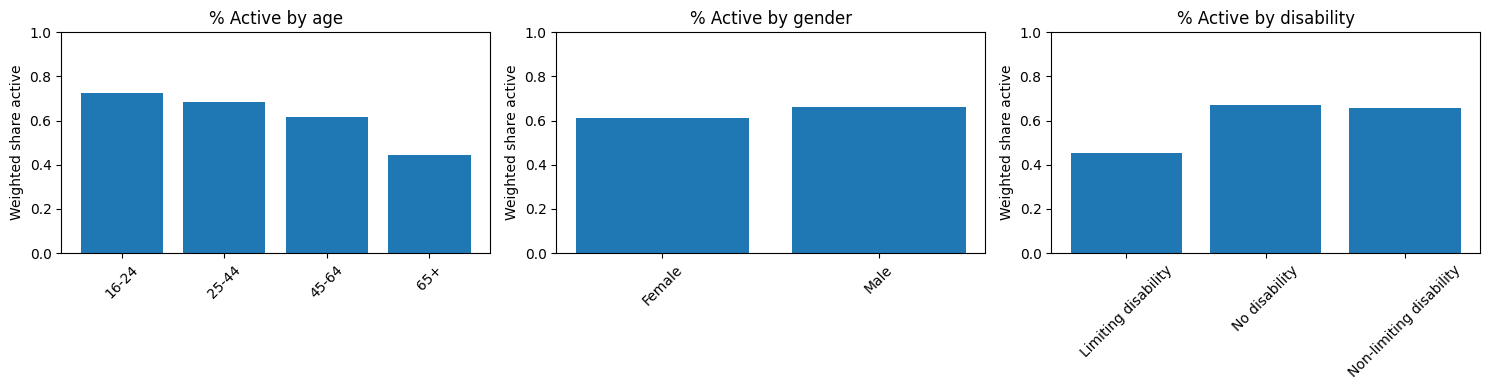

In [30]:
import matplotlib.pyplot as plt
import numpy as np

factors = ["age", "gender", "disability"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, factor in zip(axes, factors):
    res = weighted_share(london_2015_16, [factor], "activity_band", "Active")
    res = res.dropna(subset=[factor])
    ax.bar(res[factor].astype(str), res["weighted_share"])
    ax.set_title(f"% Active by {factor}"); ax.set_ylim(0, 1)
    ax.set_ylabel("Weighted share active"); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

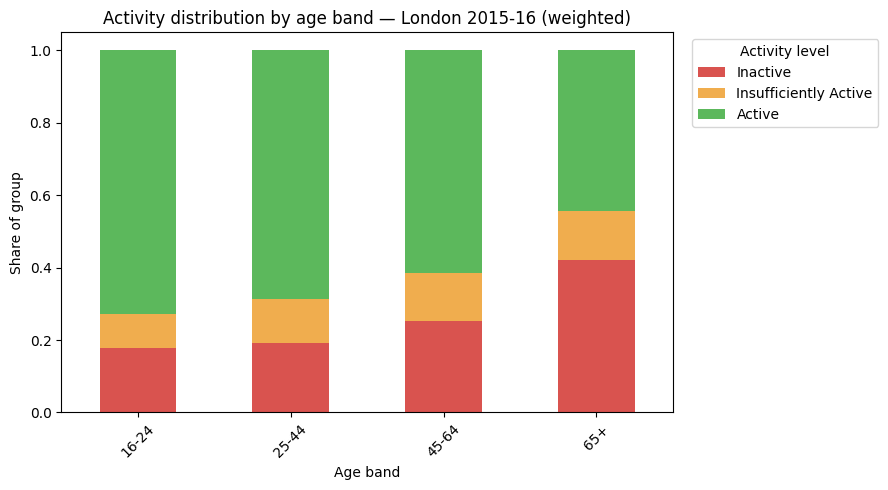

In [31]:
dist = weighted_distribution(london_2015_16, "age").dropna()
order = ["Inactive", "Insufficiently Active", "Active"]
dist = dist[[c for c in order if c in dist.columns]]
dist.plot(kind="bar", stacked=True, figsize=(9, 5),
          color=["#d9534f", "#f0ad4e", "#5cb85c"])
plt.title("Activity distribution by age band — London 2015-16 (weighted)")
plt.ylabel("Share of group"); plt.xlabel("Age band")
plt.legend(title="Activity level", bbox_to_anchor=(1.02, 1))
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

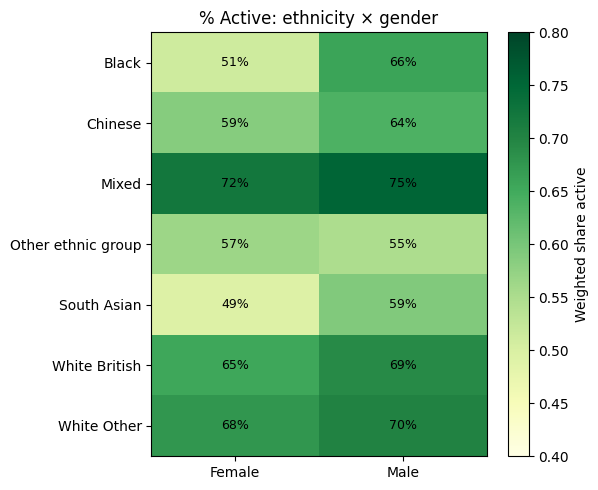

In [32]:
cross = weighted_share(london_2015_16, ["ethnicity", "gender"], "activity_band", "Active")
cross = cross.dropna(subset=["ethnicity", "gender"])
pivot = cross.pivot(index="ethnicity", columns="gender", values="weighted_share")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(pivot.values, cmap="YlGn", vmin=0.4, vmax=0.8, aspect="auto")
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=9)
ax.set_title("% Active: ethnicity × gender")
fig.colorbar(im, label="Weighted share active"); plt.tight_layout(); plt.show()

In [33]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

m = london_2015_16.dropna(subset=["activity_band","age","gender",
                                  "disability","ethnicity","weight"]).copy()
m["active"] = (m["activity_band"] == "Active").astype(int)

# Explicit reference categories so odds ratios read intuitively:
#   disability -> "No disability"   (so disability shows as a PENALTY, OR < 1)
#   ethnicity  -> "White British"   (the largest group, natural baseline)
#   gender     -> "Female"          (Male read relative to Female)
# Age reference is the first band alphabetically (youngest) — usually what you want.
# NOTE: the reference strings below must match your data's labels EXACTLY. If your
# age labels are like "16-34", set Treatment(reference="16-34") too if you prefer.
model = smf.glm(
    'active ~ C(age) '
    '+ C(gender, Treatment(reference="Female")) '
    '+ C(disability, Treatment(reference="No disability")) '
    '+ C(ethnicity, Treatment(reference="White British"))',
    data=m,
    family=sm.families.Binomial(),
    freq_weights=m["weight"],
).fit()

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 active   No. Observations:                17575
Model:                            GLM   Df Residuals:                 27038.75
Model Family:                Binomial   Df Model:                           12
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -16653.
Date:                Mon, 22 Jun 2026   Deviance:                       33307.
Time:                        12:10:15   Pearson chi2:                 2.71e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1007
Covariance Type:            nonrobust                                         
                                                                                     coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------

In [34]:
or_table = pd.DataFrame({
    "odds_ratio": np.exp(model.params),
    "p_value": model.pvalues,
    "ci_low": np.exp(model.conf_int()[0]),
    "ci_high": np.exp(model.conf_int()[1]),
}).round(3)
print(or_table)

                                                    odds_ratio  p_value  \
Intercept                                                3.932    0.000   
C(age)[T.25-44]                                          0.787    0.000   
C(age)[T.45-64]                                          0.547    0.000   
C(age)[T.65+]                                            0.273    0.000   
C(gender, Treatment(reference="Female"))[T.Male]         1.188    0.000   
C(disability, Treatment(reference="No disabilit...       0.512    0.000   
C(disability, Treatment(reference="No disabilit...       1.103    0.013   
C(ethnicity, Treatment(reference="White British...       0.531    0.000   
C(ethnicity, Treatment(reference="White British...       0.521    0.000   
C(ethnicity, Treatment(reference="White British...       0.976    0.749   
C(ethnicity, Treatment(reference="White British...       0.491    0.000   
C(ethnicity, Treatment(reference="White British...       0.423    0.000   
C(ethnicity, Treatment(re

In [35]:
# Reusable data-quality audit for any processed wave. Runs the five checks:
#   1) missingness per analysis column   2) weight validity (positive, non-missing)
#   3) activity band contains only real categories (no leaked survey codes)
#   4) demographic labels decoded to readable text
#   5) all 33 London boroughs present with plausible sizes
# Prints a readable report and returns a dict of the headline numbers so you can
# compare waves at a glance. Diagnostic only — it never modifies the data.
def audit_wave(df, meta, wave_key="", la_var="LA"):
    print(f"===== AUDIT: {wave_key} =====")
    n = len(df)
    print(f"Rows: {n:,}")

    # 1) Missingness per column
    cols = [c for c in ["activity_band","ethnicity","gender","age","disability","weight"]
            if c in df.columns]
    miss = df[cols].isna().mean().round(3).sort_values(ascending=False)
    print("\n[1] Proportion missing per column:")
    print(miss.to_string())

    # 2) Weight validity
    w = df["weight"]
    n_bad = int((w <= 0).sum()); n_naw = int(w.isna().sum())
    print("\n[2] Weight: min={:.4f} max={:.2f} | non-positive={} missing={}".format(
        w.min(), w.max(), n_bad, n_naw))
    if n_bad or n_naw:
        print("    ^ WARNING: some rows can't be validly weighted.")

    # 3) Activity band categories (should be only the 3 real labels + NaN)
    print("\n[3] activity_band categories:")
    print(df["activity_band"].value_counts(dropna=False).to_string())

    # 4) Decoded demographic labels
    print("\n[4] Decoded label samples:")
    for c in ["ethnicity","gender","disability"]:
        if c in df.columns:
            print(f"    {c}: {list(df[c].dropna().unique())[:8]}")

    # 5) London borough coverage
    labels = meta.variable_value_labels.get(la_var, {})
    names = df[la_var].map(labels)
    n_la = names.nunique()
    print(f"\n[5] London LAs present: {n_la} (expect 33)")
    if n_la != 33:
        print("    ^ WARNING: borough count != 33 — check the filter or sample.")
    smallest = names.value_counts().tail(3)
    print("    Smallest boroughs by n:")
    print(smallest.to_string())

    print("=" * (14 + len(str(wave_key))), "\n")
    return {"wave": wave_key, "rows": n,
            "miss_activity": float(miss.get("activity_band", 0)),
            "miss_weight": float(miss.get("weight", 0)),
            "miss_ethnicity": float(miss.get("ethnicity", 0)),
            "bad_weights": n_bad + n_naw,
            "n_londons_las": n_la}

In [36]:
report_2015_16 = audit_wave(london_2015_16, meta_2015_16, wave_key="2015_16")

===== AUDIT: 2015_16 =====
Rows: 19,887

[1] Proportion missing per column:
disability       0.065
ethnicity        0.061
age              0.011
gender           0.002
activity_band    0.000
weight           0.000

[2] Weight: min=0.0183 max=37.01 | non-positive=0 missing=0

[3] activity_band categories:
activity_band
Active                   12687
Inactive                  4724
Insufficiently Active     2476

[4] Decoded label samples:
    ethnicity: ['White British', 'White Other', 'South Asian', 'Other ethnic group', 'Black', 'Mixed', 'Chinese']
    gender: ['Female', 'Male']
    disability: ['No disability', 'Non-limiting disability', 'Limiting disability']

[5] London LAs present: 33 (expect 33)
    Smallest boroughs by n:
LA
E09000017 Hillingdon        486
E09000025 Newham            486
E09000001 City of London    267



## Wave 1 (2015–16) — Findings, Data Quality & Modelling

### What this notebook does
Takes the raw Active Lives 2015–16 SPSS file (198,911 respondents, 3,165 variables), filters to
the 33 Greater London local authorities, decodes and cleans the variables of interest, audits
data quality, and produces **survey-weighted** activity figures — overall, by demographic factor,
and via a weighted logistic regression. The logic is wave-agnostic: only `WAVE_CONFIG` changes.

### Key decisions
- **Activity measure:** `MEMS7GR_SPORTCOUNT_A01` (Sport England "count" definition; 0=Inactive,
  1=Insufficiently Active, 2=Active). National weighted active rate (**62.1%**) reproduces SE's
  published 2015–16 headline (~61%). The "fund" (54.6%) and pre-2016 (40.2%) definitions were
  rejected as they don't match the headline.
- **Weighting:** all percentages use the survey weight `wt_final`; no figure is a raw row count.
- **Missing data:** survey codes −90 to −99 recoded to missing; not imputed.
- **Geography:** London identified via the stable ONS GSS code prefix `E09`.

### Data quality — audit results
London analytic sample: **19,887 respondents across all 33 boroughs**.

| Check | Result |
|---|---|
| Activity outcome / weight missing | **0.0%** (complete); all weights positive (0.018–37.0) |
| Ethnicity / disability missing | 6.1% / 6.5% (item non-response) |
| Age / gender missing | 1.1% / 0.2% |
| Activity categories | Only the 3 valid labels — no leaked survey codes |
| Borough coverage | 33 of 33 London LAs present |

### Headline results — Greater London, 2015–16
- **Overall active rate: 63.5%** (weighted), slightly above the national 62.1%.

**Weighted % active by factor (unadjusted):**
| Factor | Pattern |
|---|---|
| **Age** | 16–24: 72.7% → 25–44: 68.5% → 45–64: 61.6% → 65+: 44.4% |
| **Gender** | Male 66.1% vs Female 61.1% |
| **Disability** | No disability 67.3%, non-limiting 65.7%, **limiting 45.3%** |
| **Ethnicity** | White Other 68.9% / White British 67.1% highest; South Asian 54.7%, Other 55.6% lowest |

### Adjusted analysis (weighted logistic regression, n≈17,575)
Odds of being active, holding age, gender, disability and ethnicity constant. Reference
categories: **16–24, Female, No disability, White British**. OR < 1 = less likely to be active
than the reference; OR > 1 = more likely.

| Factor (vs reference) | Odds ratio | Note |
|---|---|---|
| Age 25–44 | 0.79 | declines with age |
| Age 45–64 | 0.55 | |
| Age 65+ | 0.27 | steepest single effect |
| Male (vs Female) | 1.19 | |
| Limiting disability (vs none) | **0.51** | roughly halves the odds |
| Non-limiting disability | 1.10 | slightly higher (p=0.013) |
| Black (vs White British) | 0.53 | |
| Chinese | 0.52 | |
| Mixed | 0.98 | not significant (p=0.75) |
| Other ethnic group | 0.49 | |
| South Asian | 0.42 | largest ethnic deficit |
| White Other | 0.82 | |

**Interpretation:** age is the dominant gradient — the 65+ group has roughly a quarter of the
odds of being active compared with 16–24-year-olds. Limiting disability roughly halves the odds.
With White British as the baseline, all ethnic groups except Mixed are significantly less likely
to be active after adjustment, with South Asian and "Other" showing the largest gaps — and these
persist once age and disability composition are accounted for, so they are not merely artefacts
of those groups' age profiles.

### Caveats
- **Inference:** `freq_weights` gives reliable odds ratios but understates standard errors;
  treat p-values/CIs as optimistic. For design-based inference use a survey package.
- **Small bases:** Chinese (n=319), Mixed (n=522); borough-level City of London (n=267).
- **Scope:** Active Lives is 16+; the `Age5` "14–15" band was checked and is empty/out-of-scope
  for the adult London sample.
- These are **repeated cross-sections**, not the same individuals over time.

### Next steps
- Add waves 2016–17 … 2023–24 as new `WAVE_CONFIG` entries; run `audit_wave` on each.
- **Harmonise** categories across waves (activity definition, ethnicity, age bands).
- Stack into a single London panel for trend analysis and forecasting.

In [37]:
labels = meta_2015_16.variable_value_labels["LA"]
london = {code: lbl for code, lbl in labels.items() if str(lbl).startswith("E09")}
print(len(london))                       # must be 33
for code, lbl in sorted(london.items(), key=lambda x: x[1]):
    print(lbl)                           # eyeball the 33 borough names

33
E09000001 City of London
E09000002 Barking and Dagenham
E09000003 Barnet
E09000004 Bexley
E09000005 Brent
E09000006 Bromley
E09000007 Camden
E09000008 Croydon
E09000009 Ealing
E09000010 Enfield
E09000011 Greenwich
E09000012 Hackney
E09000013 Hammersmith and Fulham
E09000014 Haringey
E09000015 Harrow
E09000016 Havering
E09000017 Hillingdon
E09000018 Hounslow
E09000019 Islington
E09000020 Kensington and Chelsea
E09000021 Kingston upon Thames
E09000022 Lambeth
E09000023 Lewisham
E09000024 Merton
E09000025 Newham
E09000026 Redbridge
E09000027 Richmond upon Thames
E09000028 Southwark
E09000029 Sutton
E09000030 Tower Hamlets
E09000031 Waltham Forest
E09000032 Wandsworth
E09000033 Westminster


In [38]:
print(meta_2015_16.variable_value_labels.get("Age5"))

{-99.0: 'Missing, should have been answered', -98.0: 'Not applicable: Survey routing', -97.0: 'Incorrectly multicoded', -96.0: 'Out of range', -95.0: "Cannot give an estimate / Don't know", -94.0: 'Prefer not to say', -93.0: 'Not applicable: Postal response', -92.0: 'Not applicable: Phase 1 case', -91.0: 'Not applicable: Phase 2 case', -90.0: 'Not applicable: Not asked to this group', 1.0: '14-15', 2.0: '16-24', 3.0: '25-44', 4.0: '45-64', 5.0: '65+'}
